<a href="https://colab.research.google.com/github/GustavoGarcia627/Analisis-num-rico---Famaf/blob/main/2026_Practico_6_numerico_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

**Ejercicio 1:** Escribir dos funciones llamadas `jacobi`y `gseidel` que reuelvan sistemas lineales $Ax=b$ usando los métodos de Jacobi y Gauss-Seidel, respectivamente. La salida debe ser `[x,k]` donde `x`es la solucion aproximada y `k`es la cantidad de iteraciones realizadas. Deber tener entrada `(A,b,err,mit)` con `A`$\in \mathbb R^{n  \times n}$, `b`$\in \mathbb R^n$, `err` la tolerancia del error y `mit` la cantidad maxima de iteraciones. El algoritmo debe para si $\| x^{(k)}-x^{(k-1)}\|_{\infty} \le$`err` o k>= `mit`

In [ ]:
def jacobi(A: list, b: list, err: float, mit: int) -> tuple:
    '''
    Pre: A: matriz nxn, b: n-vector, err: tolerancia error, mit: máximo de iteraciones
    Pos: (x, k): Solucion aproximada y las iteraciones realizadas
    '''
    n = len(b)
    x = np.zeros(n)
    u = np.zeros(n) # Vector auxiliar para la nueva iteración

    for k in range(1, mit + 1): # Empezamos en 1 para contar bien las iteraciones
        for i in range(0, n):
            sum1 = 0
            sum2 = 0

            # Elementos a la izquierda de la diagonal (0 hasta i-1)
            for j in range(0, i):
                sum1 += A[i][j] * x[j]

            # Elementos a la derecha de la diagonal (i+1 hasta n-1)
            for j in range(i + 1, n):
                sum2 += A[i][j] * x[j]

            # Fórmula de Jacobi
            u[i] = (1 / A[i][i]) * (b[i] - sum1 - sum2)

        # Calculamos la norma euclidea usando NumPy
        normuMx = np.linalg.norm(u - x)

        # Si cumple la tolerancia, terminamos
        if normuMx < err:
            return (u.copy(), k)

        # Actualizamos x para la siguiente iteración
        x = u.copy()

    return (x, mit)

In [ ]:
def gseidel(A: list, b: list, err: float, mit: int) -> tuple:
    '''
    Pre: A: matriz nxn, b: n-vector, err: tolerancia error, mit: máximo de iteraciones
    Pos: x: Solucion aproximada, k: Iteraciones realizadas
    '''
    n = len(b)
    x = np.ones(n)  # Vector de la iteración anterior
    u = np.ones(n)  # Vector de la iteración actual

    for k in range(1, mit + 1):
        u = x.copy()
        for i in range(0, n):
            sum1 = 0
            sum2 = 0

            # Sumatoria 1:
            for j in range(0, i):
                sum1 += A[i][j] * u[j]

            # Sumatoria 2:
            for j in range(i + 1, n):
                sum2 += A[i][j] * x[j]
            u[i] = (1 / A[i][i]) * (b[i] - sum1 - sum2)

        # Calculamos la norma de ||u - x||
        normuMx = np.linalg.norm(u - x)
        if normuMx < err:
            return (u, k)
        # Actualizamos x con los nuevos valores de u para la siguiente iteración
        x = u.copy()

    return (x, mit)

**Ejercicio 2** usar los métodos de jacobi y Gauss-Seidel y resolver:

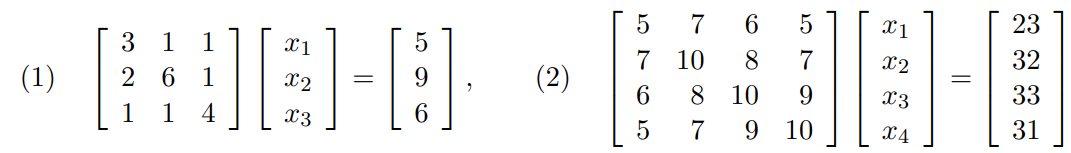

con una tolerancia de $10^{-11}$ para (1) y $10^{-4}$ para (2). ¿Cuántas iteraciones son necesarias en cada caso para alcanzar la precisión deseada?

In [ ]:
#Ejercicio 2.1
A = [ [3,1,1],[2,6,1],[1,1,4] ]
b = [5,9,6]

print(jacobi(A,b,10e-11,100))

(array([1., 1., 1.]), 43)


**Respuesta:** Le toma 43 iteraciones para llegar a la solución

In [ ]:
#Ejercicio 2.2
A = [[5,7,6,5], [7,10,8,7],[6,8,10,9],[5,7,9,10]]
b = [23,32,33,31]

print(gseidel(A,b,10e-4,100))

(array([1., 1., 1., 1.]), 1)


**Respuesta:** Le toma 1 sola iteración para converger a la solución

**Ejercicio 3** Escribir dos funciones en `python` llamadas `soltrsup` y `soltrinf` que resuelva un sistema lineal $Ax=b$ donnde $A$ es una matriz triangular (Superior e inferior respectivamente). La entrada debe ser `(A,b)` con `A`$\in \mathbb R^{n \times n}$ matriz triangular y `b`$\in \mathbb R^n$, y la salida debe ser la solución `x`. Se debe imprimir un mensaje de error si la matriz es singular

In [ ]:
def soltrsup(A: list, b: list) -> list:
  '''
  Pre: A: Matriz nxn triangular superior, b: Vector R**n
  Pos: x: Solución del sistema (o lista vacía si es singular)
  '''
  A = np.array(A, dtype=float)
  b = np.array(b, dtype=float)
  n = len(b)

  # 1. Verificar singularidad
  # En una matriz triangular, el determinante es SOLO el producto de la diagonal.
  # Si algún elemento de la diagonal es 0, la matriz es singular.
  if np.any(np.diag(A) == 0):
    return []

  # Inicializamos el vector solución x con ceros
  x = np.zeros(n)

  # 2. Sustitución hacia atrás (de la última fila a la primera)
  # range(n-1, -1, -1) va desde n-1 bajando hasta 0
  for i in range(n - 1, -1, -1):
    suma = 0
      # Sumamos los términos de las incógnitas que ya conocemos (a la derecha de la diagonal)
    for j in range(i + 1, n):
      suma += A[i][j] * x[j]

      # Despejamos la incógnita x[i]
    x[i] = (b[i] - suma) / A[i][i]

  return list(x)

In [ ]:
def soltrinf_v1(A:list,b:list)->list:
  '''
  Pre: A: matriz nxn triangular inferior, b: vector n
  Pos: Devuelve una lista con la solución Ax=b
  '''
  n = len(b)
  #Verificamos singularidad
  #Determinante de triangular superior es producto de la diagonal
  if np.any(np.diag(A) == 0):
    return []

  #Iniciamos con el vector cero:
  x = np.zeros(n)

  #Caso base
  x[0] = (b[0])/A[0][0] #caso base
  acum = x[0]

  #Resolvemos hacia abajo:
  for i in range(1,n):
    x[i] = (b[i]-acum)/A[i][i]
    acum+=x[i]
  return x

In [ ]:
#Intento sin iteraciones con matriz 3x3
MPrueba= [[1,0,0],[1,1,0],[1,1,1]]
b = [2,3,4]
#la solución será = [2,1,1]

n = len(b)
x2 = np.zeros(n)

#for i in range(n):
#  for j in range(i+1):
#    print(i)
x2[0] = (b[0])/MPrueba[0][0]
x2[1] = (b[1]-x2[0])/MPrueba[1][1]
x2[2] = (b[2]-x2[1]-x2[0])/MPrueba[2][2]

print(x2)

[2. 1. 1.]


In [ ]:
#Mismo intento con iteraciones
MPrueba= [[2,0,0],[1,1,0],[1,5,1]]
b = [2,3,4]
#la solución será = [2,1,1]

n = len(b)
x2 = np.zeros(n)
acum =0
x2[0] = (b[0])/MPrueba[0][0] #caso base
acum = x2[0]
for i in range(1,n):
  x2[i] = (b[i]-acum)/MPrueba[i][i]
  acum+=x2[i]
print(x2)


[1. 2. 1.]


La funcion anterior no srive porque se asume directamente que la diagonal es puramente formada por coordenadas igual a 1. Para que se evite el error de asumir que los elementos de la diagonal es igual a 1, hago el producto entre la matriz `A` y el vector `x` para asumir esos valores. Además, esto deja excento al caso base y se puede hacer una iteración directa

In [ ]:
def soltrinf(A: list, b: list) -> list:
    '''
    Pre: A: matriz nxn triangular inferior, b: vector n
    Pos: Devuelve una lista con la solución Ax=b
    '''
    # Convertimos a arrays de numpy para poder operar correctamente
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)

    # Verificamos singularidad
    if np.any(np.diag(A) == 0):
        print("La matriz es singular (no tiene solución única).")
        return []

    # Inicializamos el vector solución con ceros
    x = np.zeros(n)

    # Sustitución hacia adelante
    for i in range(n):
        # A[i, :i] toma los coeficientes de la fila i hasta antes de la diagonal
        # x[:i] toma las respuestas ya calculadas
        # np.dot calcula el producto punto (la sumatoria)
        acum = np.dot(A[i, :i], x[:i])

        x[i] = (b[i] - acum) / A[i, i]

    return list(x)

In [ ]:
matriz = [[2,0,0],[1,1,0],[1,5,1]]
b = [2,3,4]
print(soltrinf(matriz,b))

[np.float64(1.0), np.float64(2.0), np.float64(-7.0)]


**Ejercicio 4 a)** Escribir una función llamda `"egauss"` que implemente el método de elimniación Gaussiana. Debe tener entrada `(A,b)` con `A`$\in \mathbb R^{n \times n}$ y `b`$\in \mathbb R^n$, con salida `[U,y]` con `U`$ \in \mathbb R^{n \times n}$ triangular superior e `y`$\in \mathbb R^n$



In [ ]:
# Probamos para el siguiente caso:
A = np.array([[1,1,1],[2,-1,3],[1,2,-2]],dtype=float)
b = np.array([6,9,-1],dtype=float)
#la solución debe ser x=[1,2,3]
xsol=np.array([1,2,3],dtype=float)

n = len(b)
x = np.zeros(n)

#F1 = F1 - (a10/a01)* F0
#F2 = F3 - (a20/a01)* F0
valor = A[1][0]/A[0][1]
A[1]=A[1]-(valor)* A[0]
b[1]=b[1]-(valor)* b[0]
valor = A[2][0]/A[0][1]
A[2]=A[2]-(valor)* A[0]
b[2]=b[2]-(valor)* b[0]


#F2 = F2 - (a01/a11)*F1
valor = A[0][1]/A[1][1]
A[2]= A[2]-(valor)*A[1]
b[2]= b[2]-(valor)*b[1]


In [ ]:
#modelo iterativo:
A = np.array([[1,1,1],[2,-1,3],[1,2,-2]],dtype=float)
b = np.array([6,9,-1],dtype=float)
#la solución debe ser x=[1,2,3]
xsol=np.array([1,2,3],dtype=float)

n = len(b)
x = np.zeros(n)

for i in range(n):
  # i representa la fila del pivote actual (A[i][i])
  for j in range(i + 1, n):
      # j representa las filas que están por debajo del pivote y que queremos hacer cero
      factor = A[j][i] / A[i][i]

      # Operación elemental en la fila de la matriz A y el vector b
      A[j] = A[j] - factor * A[i]
      b[j] = b[j] - factor * b[i]
print(A)
print(b)

[[ 1.          1.          1.        ]
 [ 0.         -3.          1.        ]
 [ 0.          0.         -2.66666667]]
[ 6. -3. -8.]


In [ ]:
#Ejercicio 4.1.
def egauss(A,b)->list:
  '''
  Pre: A: matriz nxn; b: vector n
  Pos: U: matriz triangular superior reducida Y: vector reducido
  '''
  n=len(b)
  x = np.zeros(n)
  for i in range(n):
  # i representa la fila del pivote actual (A[i][i])
    for j in range(i + 1, n):
      # j representa las filas que están por debajo del pivote y que queremos hacer cero
      factor = A[j][i] / A[i][i]

      # Operación elemental en la fila de la matriz A y el vector b
      A[j] = A[j] - factor * A[i]
      b[j] = b[j] - factor * b[i]
  return(A,b)

**Ejercicio 4b)** Escribir una función llamada `soleg` que resuelva sistemas lineales $Ax=b$ usando eliminación Gaussiana y resolviendo el sistema triangular superior $Ux=y$ (Usando `soltrsup`). Debe tener entrada `(A,b)` con `A`$\in \mathbb R^{n \times n}$ y `b`$\in \mathbb R^n$ y, la salida debe ser la solución `x`

In [ ]:
def soleg(A:list,b:list)->list:
  '''
  Pre: A: matriz nxn b: vector n
  Pos: Devuelve solución Ax=b
  '''
  U,b2=egauss(A,b)
  x = soltrsup(U,b2)
  return x

**Ejercicio 5** Escribir una función llamada `sollu` que resuelva sistemas lineales $Ax = b$ usando descomposición $LU$ con pivoteo (Para obtener dichas descomposición investigar el paquete de la librería scipy: "linalg") para luego resolver $LY=P^{-1}b$ (¿Cómo se puede obtener la inversa de una matriz de pivoteo?) y $Ux=y$ usando `soltrinf` y `soltrsup`. La salida debe ser la solución `x` y debe tener entrada `(A,b)` `A`$\in \mathbb R ^{n \times n}$ y `b`$\in \mathbb R^n$.

In [ ]:
#Ejercicio 5
from scipy.linalg import lu
from scipy.linalg import inv

Importamos de la libreria scipy.linalg la función `lu`: de la siguiente forma `p,l,u=lu(A)`

*   `p`-> Matriz de permutación
*   `l`-> Matriz "lower"
*   `u`-> Matriz "uper"

Además la función `inv` devuelve la inversa de una matriz



In [ ]:
#ejemplo
A = np.array([[1,1,1],[2,-1,3],[1,2,-2]],dtype=float)
p,l,u = lu(A)

B = np.dot(l,u)
#print(B)

print(np.dot(p,B)) #=A
print(" ")
print(inv(p)) #Inversa de p

[[ 1.  1.  1.]
 [ 2. -1.  3.]
 [ 1.  2. -2.]]
 
[[-0.  1. -0.]
 [-0.  0.  1.]
 [ 1.  0.  0.]]


In [ ]:
def sollu(A:list,b:list)->list:
  '''
  :pre: A: matriz nxn, b: vector dimensión n
  :pos: Devuelve solución Ax=b con descomposición LU con pivoteo
  '''
  p,l,u = lu(A)

  #Inversa de p
  invP = inv(p)

  #Matriz de pivoteo por b
  pb   = np.dot(invP,b)

  #Hacemos ly=pb
  y = soltrinf(l,pb)

  #Hacemos ux=y
  x=soltrsup(u,y)
  return x

In [ ]:
A = np.array([[1,1,1],[2,-1,3],[1,2,-2]],dtype=float)
b = b = np.array([6,9,-1],dtype=float)

#Devuelve una solución aproximada a [1,2,3]
print(sollu(A,b))

[np.float64(1.0000000000000004), np.float64(1.9999999999999993), np.float64(2.9999999999999996)]


**Ejercicio 6:** Comparar las soluciones dadas por `soleg` y `sollu` al resolver $AX=b$ con:

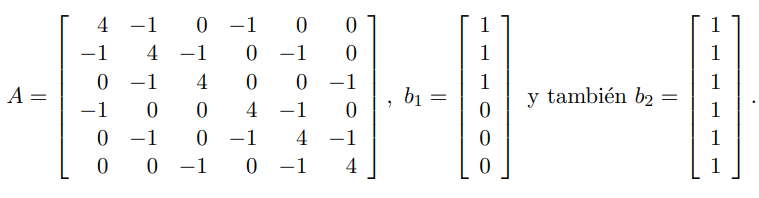

In [ ]:
#Ejercicio 6
A = np.array([[4,-1,0,-1,0,0],
              [-1,4,-1,0,-1,0],
              [0,-1,4,0,0,-1],
              [-1,0,0,4,-1,0],
              [0,-1,0,-1,4,-1],
              [0,0,-1,0,-1,4]],
             dtype=float)
b1 = np.array([1,1,1,0,0,0],dtype=float)
b2 = np.array([1,1,1,1,1,1],dtype=float)

In [ ]:
xg1 = soleg(A,b1)
xlu1= sollu(A,b1)
print(xg1)
print(xlu1)

[np.float64(0.4161490683229814), np.float64(0.5093167701863354), np.float64(0.4161490683229813), np.float64(0.15527950310559005), np.float64(0.20496894409937888), np.float64(0.15527950310559005)]
[np.float64(0.4161490683229814), np.float64(0.5093167701863354), np.float64(0.4161490683229813), np.float64(0.15527950310559005), np.float64(0.20496894409937888), np.float64(0.15527950310559005)]


In [ ]:
xg2 = soleg(A,b2)
xlu2= sollu(A,b2)
print(xg2)
print(xlu2)

[np.float64(0.4692951680173031), np.float64(0.49681107551932635), np.float64(0.3812421063539516), np.float64(0.38036959654988606), np.float64(0.3867070277060507), np.float64(0.294824016563147)]
[np.float64(0.4692951680173031), np.float64(0.49681107551932635), np.float64(0.3812421063539516), np.float64(0.38036959654988606), np.float64(0.3867070277060507), np.float64(0.294824016563147)]


Respuesta: Los métodos son distintos, sin embargo las soluciones son iguales